In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
project_root = Path().resolve().parent
data_dir = project_root / "data"

df_daily = pd.read_csv(data_dir / "daily_clean.csv", parse_dates=['calendarDate'])
df_act = pd.read_csv(data_dir / "activities_clean.csv", parse_dates=['date'])

print(f"daily: {df_daily.shape}")
print(f"activities: {df_act.shape}")

daily: (887, 30)
activities: (259, 32)


In [4]:
# Quick summary of daily data
df_daily.describe().round(1)

,calendarDate,totalSteps,totalDistanceMeters,activeSeconds,highlyActiveSeconds,moderateIntensityMinutes,vigorousIntensityMinutes,floorsAscendedInMeters,floorsDescendedInMeters,totalKilocalories,...,stress_high_duration,battery_charged,battery_drained,battery_high,battery_low,battery_end,battery_start,respiration_avg_waking,respiration_high,respiration_low
count,887,884.0,884.0,887.0,887.0,887.0,887.0,887.0,887.0,887.0,...,877.0,879.0,879.0,879.0,879.0,735.0,879.0,879.0,879.0,879.0
mean,2025-02-28 19:43:29.695603,9516.1,8346.3,5361.6,550.5,8.1,3.3,74.9,59.3,2358.7,...,4248.8,54.9,57.3,72.4,13.7,19.3,23.7,13.9,21.2,8.3
min,2023-12-10 00:00:00,7.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,1209.0,...,60.0,0.0,0.0,5.0,5.0,5.0,5.0,12.0,16.0,4.0
25%,2024-07-18 12:00:00,6078.0,4960.0,2950.0,182.0,0.0,0.0,34.9,26.1,2170.5,...,1500.0,42.0,44.0,58.0,5.0,8.0,10.0,14.0,20.0,7.0
50%,2025-03-01 00:00:00,8972.0,7316.5,4747.0,324.0,0.0,0.0,62.0,48.1,2300.0,...,3120.0,60.0,61.0,78.0,12.0,18.0,21.0,14.0,21.0,8.0
75%,2025-10-09 12:00:00,12089.0,10122.5,7006.0,656.5,10.0,1.0,99.6,75.0,2494.5,...,5520.0,71.0,73.0,92.0,20.0,28.0,32.0,14.0,22.0,9.0
max,2026-05-21 00:00:00,33001.0,32892.0,31964.0,5591.0,313.0,45.0,585.2,623.3,5021.0,...,29040.0,114.0,94.0,100.0,43.0,57.0,93.0,17.0,29.0,14.0
std,NaN,4707.3,5257.6,3519.4,620.4,19.5,9.0,59.2,52.0,293.8,...,4032.5,22.7,20.5,24.1,8.7,12.2,17.2,0.7,1.7,1.5


In [18]:
# Summary stats — daily health
print("=== DAILY HEALTH SUMMARY ===")
print(f"Date range:          {df_daily['calendarDate'].min().date()} to {df_daily['calendarDate'].max().date()}")
print(f"Total days:          {len(df_daily)}")
print(f"Avg daily steps:     {df_daily['totalSteps'].mean():.0f}")
print(f"Median daily steps:  {df_daily['totalSteps'].median():.0f}")
print(f"Avg resting HR:      {df_daily['restingHeartRate'].mean():.1f} bpm")
print(f"Avg daily stress:    {df_daily['stress_avg'].mean():.1f}")
print(f"Avg battery end:     {df_daily['battery_end'].mean():.1f}")
print(f"Avg battery start:   {df_daily['battery_start'].mean():.1f}")
print(f"Avg active seconds:  {df_daily['activeSeconds'].mean():.0f} ({df_daily['activeSeconds'].mean()/60:.1f} min)")

=== DAILY HEALTH SUMMARY ===
Date range:          2023-12-10 to 2026-05-21
Total days:          887
Avg daily steps:     9516
Median daily steps:  8972
Avg resting HR:      50.1 bpm
Avg daily stress:    33.2
Avg battery end:     19.3
Avg battery start:   23.7
Avg active seconds:  5362 (89.4 min)


In [19]:
# Summary stats — workouts
print("=== WORKOUT SUMMARY ===")
print(f"Date range:              {df_act['date'].min().date()} to {df_act['date'].max().date()}")
print(f"Total workouts:          {len(df_act)}")
print(f"Workout days:            {df_daily['had_workout'].sum()} of {len(df_daily)} days ({df_daily['had_workout'].mean()*100:.1f}%)")
print(f"Avg workouts/month:      {len(df_act) / df_act['date'].dt.to_period('M').nunique():.1f}")
print(f"Avg duration:            {df_act['duration_minutes'].mean():.1f} min")
print(f"Median duration:         {df_act['duration_minutes'].median():.1f} min")
print(f"Avg HR during workout:   {df_act['avgHr'].mean():.1f} bpm")
print(f"Most common activity:    {df_act['activityType'].value_counts().index[0]} ({df_act['activityType'].value_counts().iloc[0]} sessions)")
print(f"Avg battery drain:       {df_act['differenceBodyBattery'].mean():.1f}")
print(f"Avg stress on workout days:  {df_daily[df_daily['had_workout']]['stress_avg'].mean():.1f}")
print(f"Avg stress on rest days:     {df_daily[~df_daily['had_workout']]['stress_avg'].mean():.1f}")

=== WORKOUT SUMMARY ===
Date range:              2023-12-11 to 2026-05-19
Total workouts:          259
Workout days:            241 of 887 days (27.2%)
Avg workouts/month:      9.6
Avg duration:            54.3 min
Median duration:         49.2 min
Avg HR during workout:   107.7 bpm
Most common activity:    yoga (83 sessions)
Avg battery drain:       -6.5
Avg stress on workout days:  30.3
Avg stress on rest days:     34.2


In [20]:
print("=== KEY FINDINGS ===")
print(f"Resting HR improved from ~63 bpm (Dec 2023) to ~49 bpm (2024 onward) — a {63-49} bpm drop")
print(f"Workout days associated with {34.2 - 30.3:.1f} pt lower avg stress vs rest days")
print(f"Avg battery start: {df_daily['battery_start'].mean():.1f} — consistently low, suggests incomplete overnight recovery")
print(f"Saturday most active day (median {df_daily[df_daily['day_of_week']=='Saturday']['totalSteps'].median():.0f} steps), Monday least active ({df_daily[df_daily['day_of_week']=='Monday']['totalSteps'].median():.0f} steps)")
print(f"Workout frequency increased significantly from mid-2024 onward")

=== KEY FINDINGS ===
Resting HR improved from ~63 bpm (Dec 2023) to ~49 bpm (2024 onward) — a 14 bpm drop
Workout days associated with 3.9 pt lower avg stress vs rest days
Avg battery start: 23.7 — consistently low, suggests incomplete overnight recovery
Saturday most active day (median 12314 steps), Monday least active (5951 steps)
Workout frequency increased significantly from mid-2024 onward


In [5]:
df_act['activityType'].value_counts()

activityType
yoga                 83
indoor_cycling       56
pilates              46
strength_training    24
indoor_cardio        14
bouldering           10
walking               7
pickleball            4
lap_swimming          4
hiking                4
jump_rope             3
running               1
hiit                  1
indoor_rowing         1
cycling               1
Name: count, dtype: int64

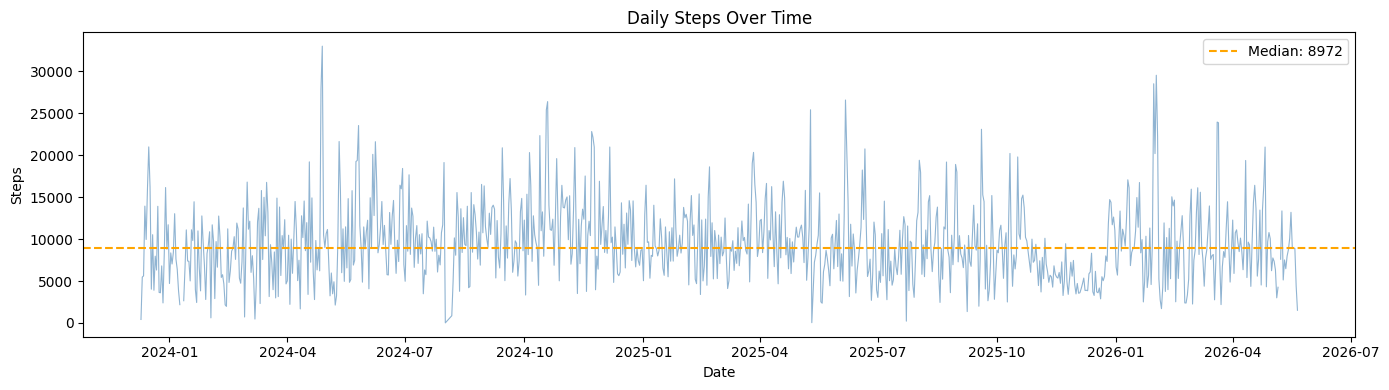

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_daily['calendarDate'], df_daily['totalSteps'], 
        color='steelblue', linewidth=0.8, alpha=0.6)
ax.axhline(df_daily['totalSteps'].median(), color='orange', 
           linewidth=1.5, linestyle='--', label=f"Median: {df_daily['totalSteps'].median():.0f}")
ax.set_title('Daily Steps Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Steps')
ax.legend()
plt.tight_layout()
plt.show()

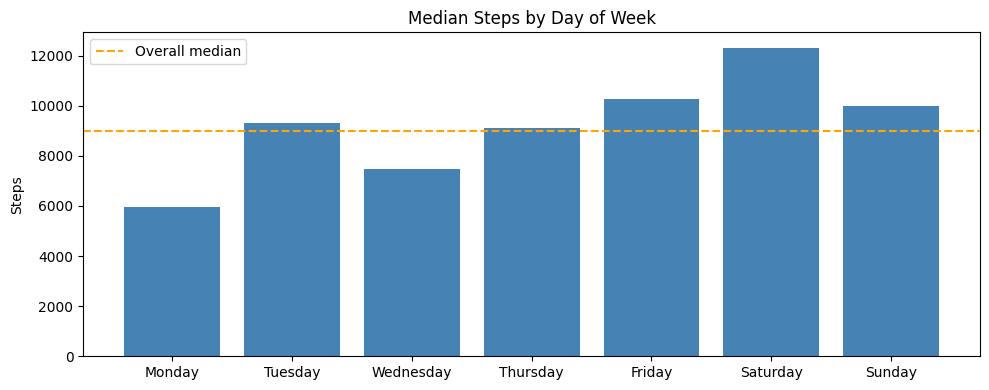

In [7]:
df_daily['day_of_week'] = df_daily['calendarDate'].dt.day_name()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

dow_steps = df_daily.groupby('day_of_week')['totalSteps'].median().reindex(dow_order)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dow_steps.index, dow_steps.values, color='steelblue')
ax.axhline(df_daily['totalSteps'].median(), color='orange', 
           linewidth=1.5, linestyle='--', label='Overall median')
ax.set_title('Median Steps by Day of Week')
ax.set_ylabel('Steps')
ax.legend()
plt.tight_layout()
plt.show()

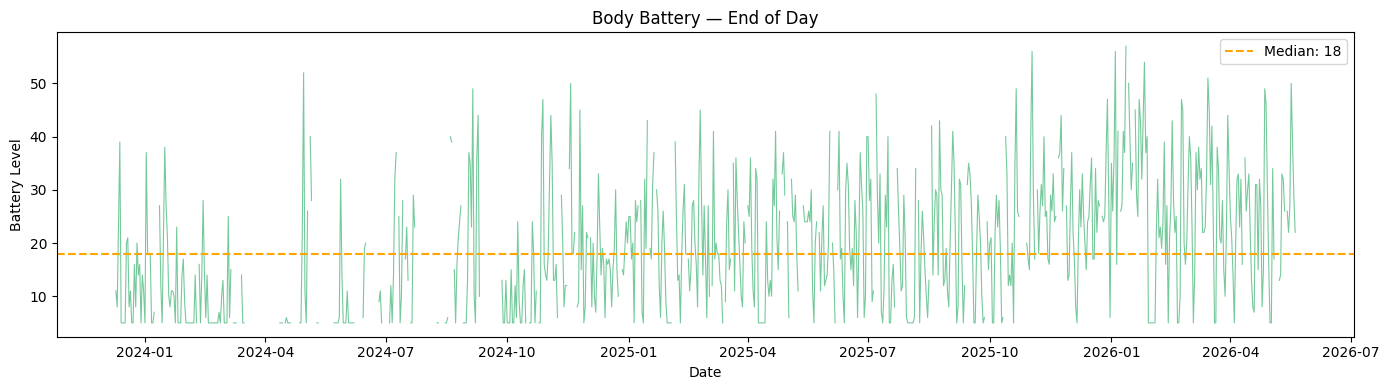

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_daily['calendarDate'], df_daily['battery_end'],
        color='mediumseagreen', linewidth=0.8, alpha=0.7)
ax.axhline(df_daily['battery_end'].median(), color='orange',
           linewidth=1.5, linestyle='--', label=f"Median: {df_daily['battery_end'].median():.0f}")
ax.set_title('Body Battery — End of Day')
ax.set_xlabel('Date')
ax.set_ylabel('Battery Level')
ax.legend()
plt.tight_layout()
plt.show()

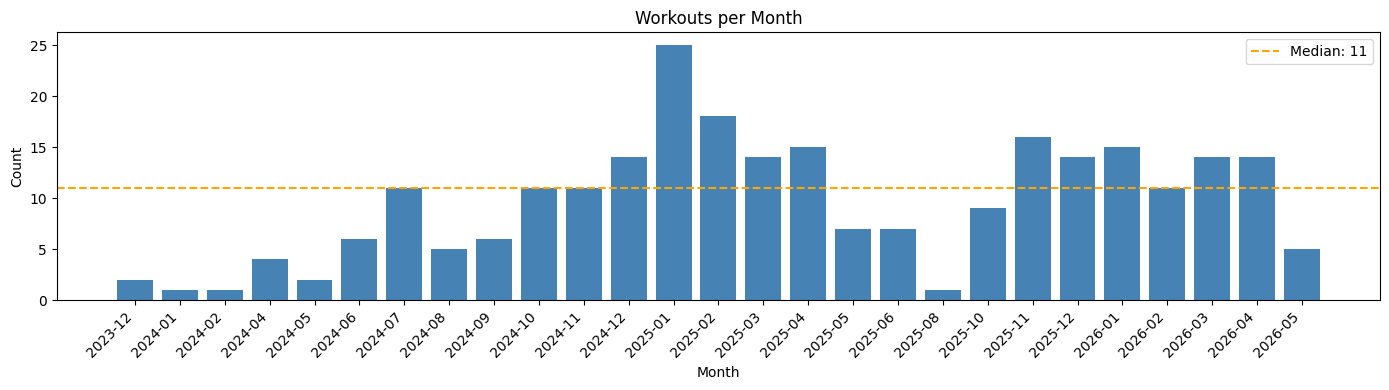

In [9]:
# Workouts per month
df_act['year_month'] = df_act['date'].dt.to_period('M')
workouts_per_month = df_act.groupby('year_month').size()

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(workouts_per_month.index.astype(str), workouts_per_month.values, color='steelblue')
ax.axhline(workouts_per_month.median(), color='orange',
           linewidth=1.5, linestyle='--', label=f"Median: {workouts_per_month.median():.0f}")
ax.set_title('Workouts per Month')
ax.set_ylabel('Count')
ax.set_xlabel('Month')
plt.xticks(rotation=45, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

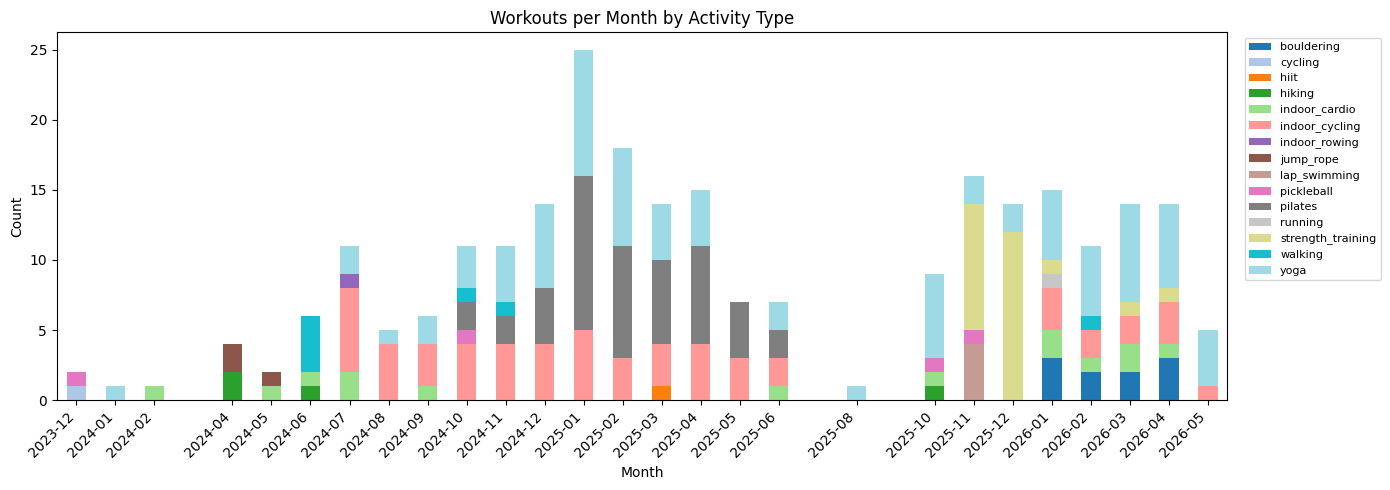

In [10]:
# Workouts per month by activity type
act_by_month = df_act.groupby(['year_month', 'activityType']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 5))
act_by_month.plot(kind='bar', stacked=True, ax=ax, colormap='tab20')
ax.set_title('Workouts per Month by Activity Type')
ax.set_ylabel('Count')
ax.set_xlabel('Month')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

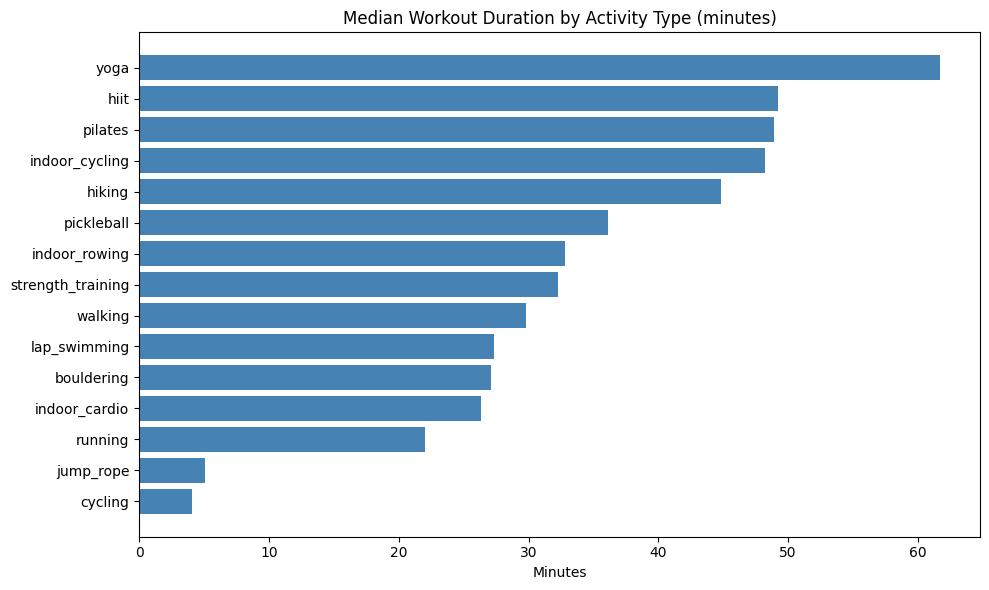

In [11]:
duration_by_type = df_act.groupby('activityType')['duration_minutes'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(duration_by_type.index, duration_by_type.values, color='steelblue')
ax.set_title('Median Workout Duration by Activity Type (minutes)')
ax.set_xlabel('Minutes')
plt.tight_layout()
plt.show()

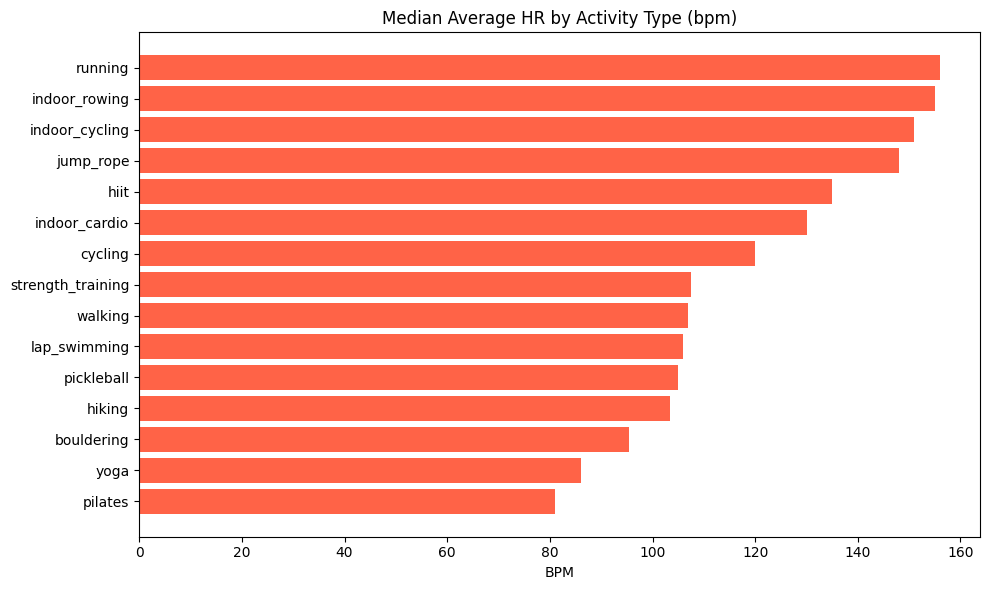

In [12]:
hr_by_type = df_act.groupby('activityType')['avgHr'].median().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(hr_by_type.index, hr_by_type.values, color='tomato')
ax.set_title('Median Average HR by Activity Type (bpm)')
ax.set_xlabel('BPM')
plt.tight_layout()
plt.show()

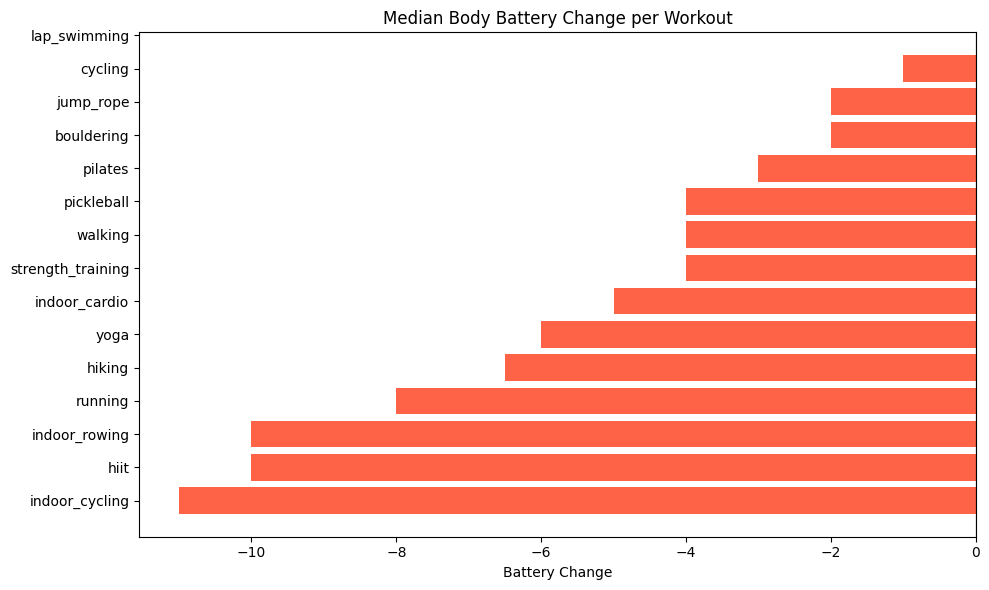

In [13]:
battery_by_type = df_act.groupby('activityType')['differenceBodyBattery'].median().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if v < 0 else 'steelblue' for v in battery_by_type.values]
ax.barh(battery_by_type.index, battery_by_type.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Median Body Battery Change per Workout')
ax.set_xlabel('Battery Change')
plt.tight_layout()
plt.show()

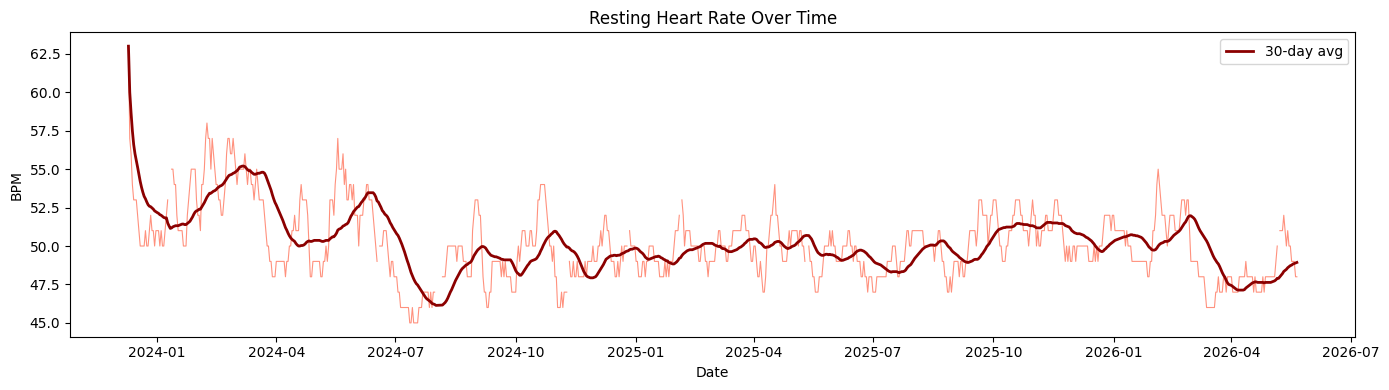

In [14]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_daily['calendarDate'], df_daily['restingHeartRate'],
        color='tomato', linewidth=0.8, alpha=0.7)

# 30-day rolling average
rolling = df_daily.set_index('calendarDate')['restingHeartRate'].rolling('30D').mean()
ax.plot(rolling.index, rolling.values, color='darkred', linewidth=2, label='30-day avg')

ax.set_title('Resting Heart Rate Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('BPM')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Get dates where a workout occurred
workout_dates = set(df_act['date'].dt.date)

# Flag workout days in daily data
df_daily['had_workout'] = df_daily['calendarDate'].dt.date.isin(workout_dates)

print(df_daily['had_workout'].value_counts())

had_workout
False    646
True     241
Name: count, dtype: int64


C:\Users\maxk6\AppData\Local\Temp\ipykernel_7296\1229406170.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([rest, workout], labels=['Rest', 'Workout'])
C:\Users\maxk6\AppData\Local\Temp\ipykernel_7296\1229406170.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([rest, workout], labels=['Rest', 'Workout'])
C:\Users\maxk6\AppData\Local\Temp\ipykernel_7296\1229406170.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([rest, workout], labels=['Rest', 'Workout'])
C:\Users\maxk6\AppData\Local\Temp\ipykernel_7296\1229406170.py:12: MatplotlibDeprecationWarning: The 'l

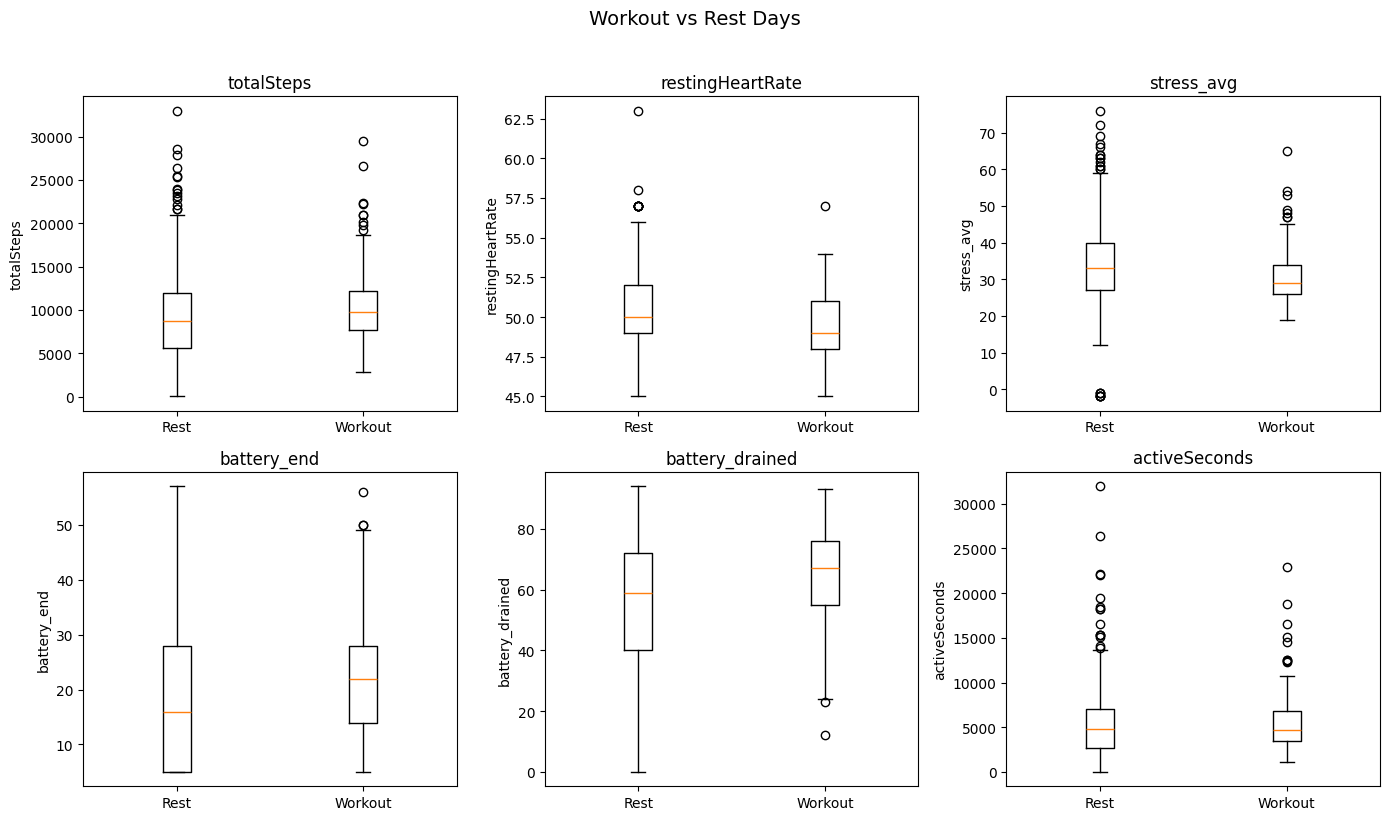

In [16]:
# Compare key metrics on workout vs rest days
metrics = ['totalSteps', 'restingHeartRate', 'stress_avg', 
           'battery_end', 'battery_drained', 'activeSeconds']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    workout = df_daily[df_daily['had_workout']][metric].dropna()
    rest = df_daily[~df_daily['had_workout']][metric].dropna()
    
    axes[i].boxplot([rest, workout], labels=['Rest', 'Workout'])
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)

plt.suptitle('Workout vs Rest Days', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

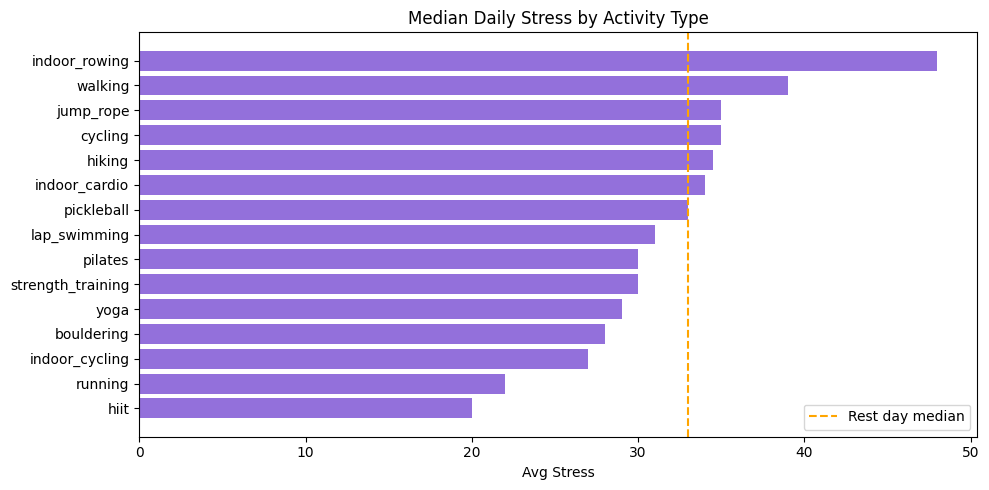

In [17]:
# Join activity type onto daily data for workout days
df_act_daily = df_act[['date', 'activityType', 'avgHr']].copy()
df_act_daily = df_act_daily.rename(columns={'date': 'calendarDate'})

# For days with multiple workouts, keep the highest intensity one
df_act_daily = df_act_daily.sort_values('avgHr', ascending=False).drop_duplicates('calendarDate')

df_merged = df_daily.merge(df_act_daily, on='calendarDate', how='left')

# Stress by activity type
stress_by_type = df_merged.groupby('activityType')['stress_avg'].median().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(stress_by_type.index, stress_by_type.values, color='mediumpurple')
ax.axvline(df_daily[~df_daily['had_workout']]['stress_avg'].median(), 
           color='orange', linewidth=1.5, linestyle='--', label='Rest day median')
ax.set_title('Median Daily Stress by Activity Type')
ax.set_xlabel('Avg Stress')
ax.legend()
plt.tight_layout()
plt.show()